# **Studikasus - Diabetes** 

## 1. Data Preparation

### 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Load Dataset

In [2]:
df = pd.read_csv('diabetes.csv')

### 1.3 Baca Dataset

In [3]:
# 5 baris teratas
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# 5 baris terbawah
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
# 10 baris acak
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
352,3,61,82,28,0,34.4,0.243,46,0
9,8,125,96,0,0,0.0,0.232,54,1
325,1,157,72,21,168,25.6,0.123,24,0
394,4,158,78,0,0,32.9,0.803,31,1
320,4,129,60,12,231,27.5,0.527,31,0
8,2,197,70,45,543,30.5,0.158,53,1
289,5,108,72,43,75,36.1,0.263,33,0
343,5,122,86,0,0,34.7,0.290,33,0
485,0,135,68,42,250,42.3,0.365,24,1
524,3,125,58,0,0,31.6,0.151,24,0


In [6]:
# Jumlah baris dan kolom
df.shape

(768, 9)

In [7]:
# Ringkasan informasi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
# Ringkasan statistik
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
# Kolom dalam dataset
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Pedigree', 'Age', 'Outcome'],
      dtype='object')

In [10]:
# Jumlah data kolom 'Outcome'
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
# Cek nilai unik salah sat kolom
print("Kategori nilai unik dalam kolom'Pregnancies'", df['Pregnancies'].unique())
print("Jumlah setiap kategori di dalam kolom 'Pregnancies' \n", df["Pregnancies"].value_counts())

Kategori nilai unik dalam kolom'Pregnancies' [ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]
Jumlah setiap kategori di dalam kolom 'Pregnancies' 
 Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64


### 1.3 Cek Nilai Kosong

In [12]:
df.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64

### 1.4 Cek Nilai Duplikat

In [13]:
df.duplicated().sum()

np.int64(0)

### 1.5 Cek Missing Values

In [14]:
# Cek jumlah nilai nol pada fitur beberapa fitur
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    print(f"{col}: {df[df[col] == 0].shape[0]} nol")

Glucose: 5 nol
BloodPressure: 35 nol
SkinThickness: 227 nol
Insulin: 374 nol
BMI: 11 nol


In [15]:
for col in ['Glucose', 'BloodPressure', 'BMI']:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))
df.fillna(df.median(), inplace=True)

In [16]:
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
679,2,101.0,58.0,17,265,24.2,0.614,23,0
503,7,94.0,64.0,25,79,33.3,0.738,41,0
320,4,129.0,60.0,12,231,27.5,0.527,31,0
345,8,126.0,88.0,36,108,38.5,0.349,49,0
171,6,134.0,70.0,23,130,35.4,0.542,29,1
581,6,109.0,60.0,27,0,25.0,0.206,27,0
561,0,198.0,66.0,32,274,41.3,0.502,28,1
584,8,124.0,76.0,24,600,28.7,0.687,52,1
727,0,141.0,84.0,26,0,32.4,0.433,22,0
234,3,74.0,68.0,28,45,29.7,0.293,23,0


In [17]:
# Cek data kosong
nan_data = df[df.isna().any(axis=1)]
nan_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome


In [18]:
df = df.drop(['Insulin', 'SkinThickness'], axis=1)

## 2. Exploratory Data Analysis

### 2.1 Cek Nilai Outlier

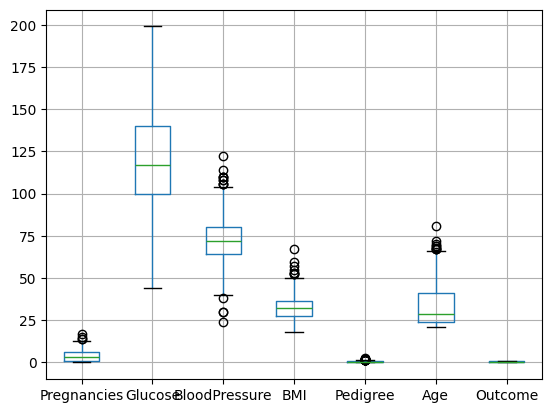

In [19]:
df.boxplot(column=df.columns.tolist())
plt.show()

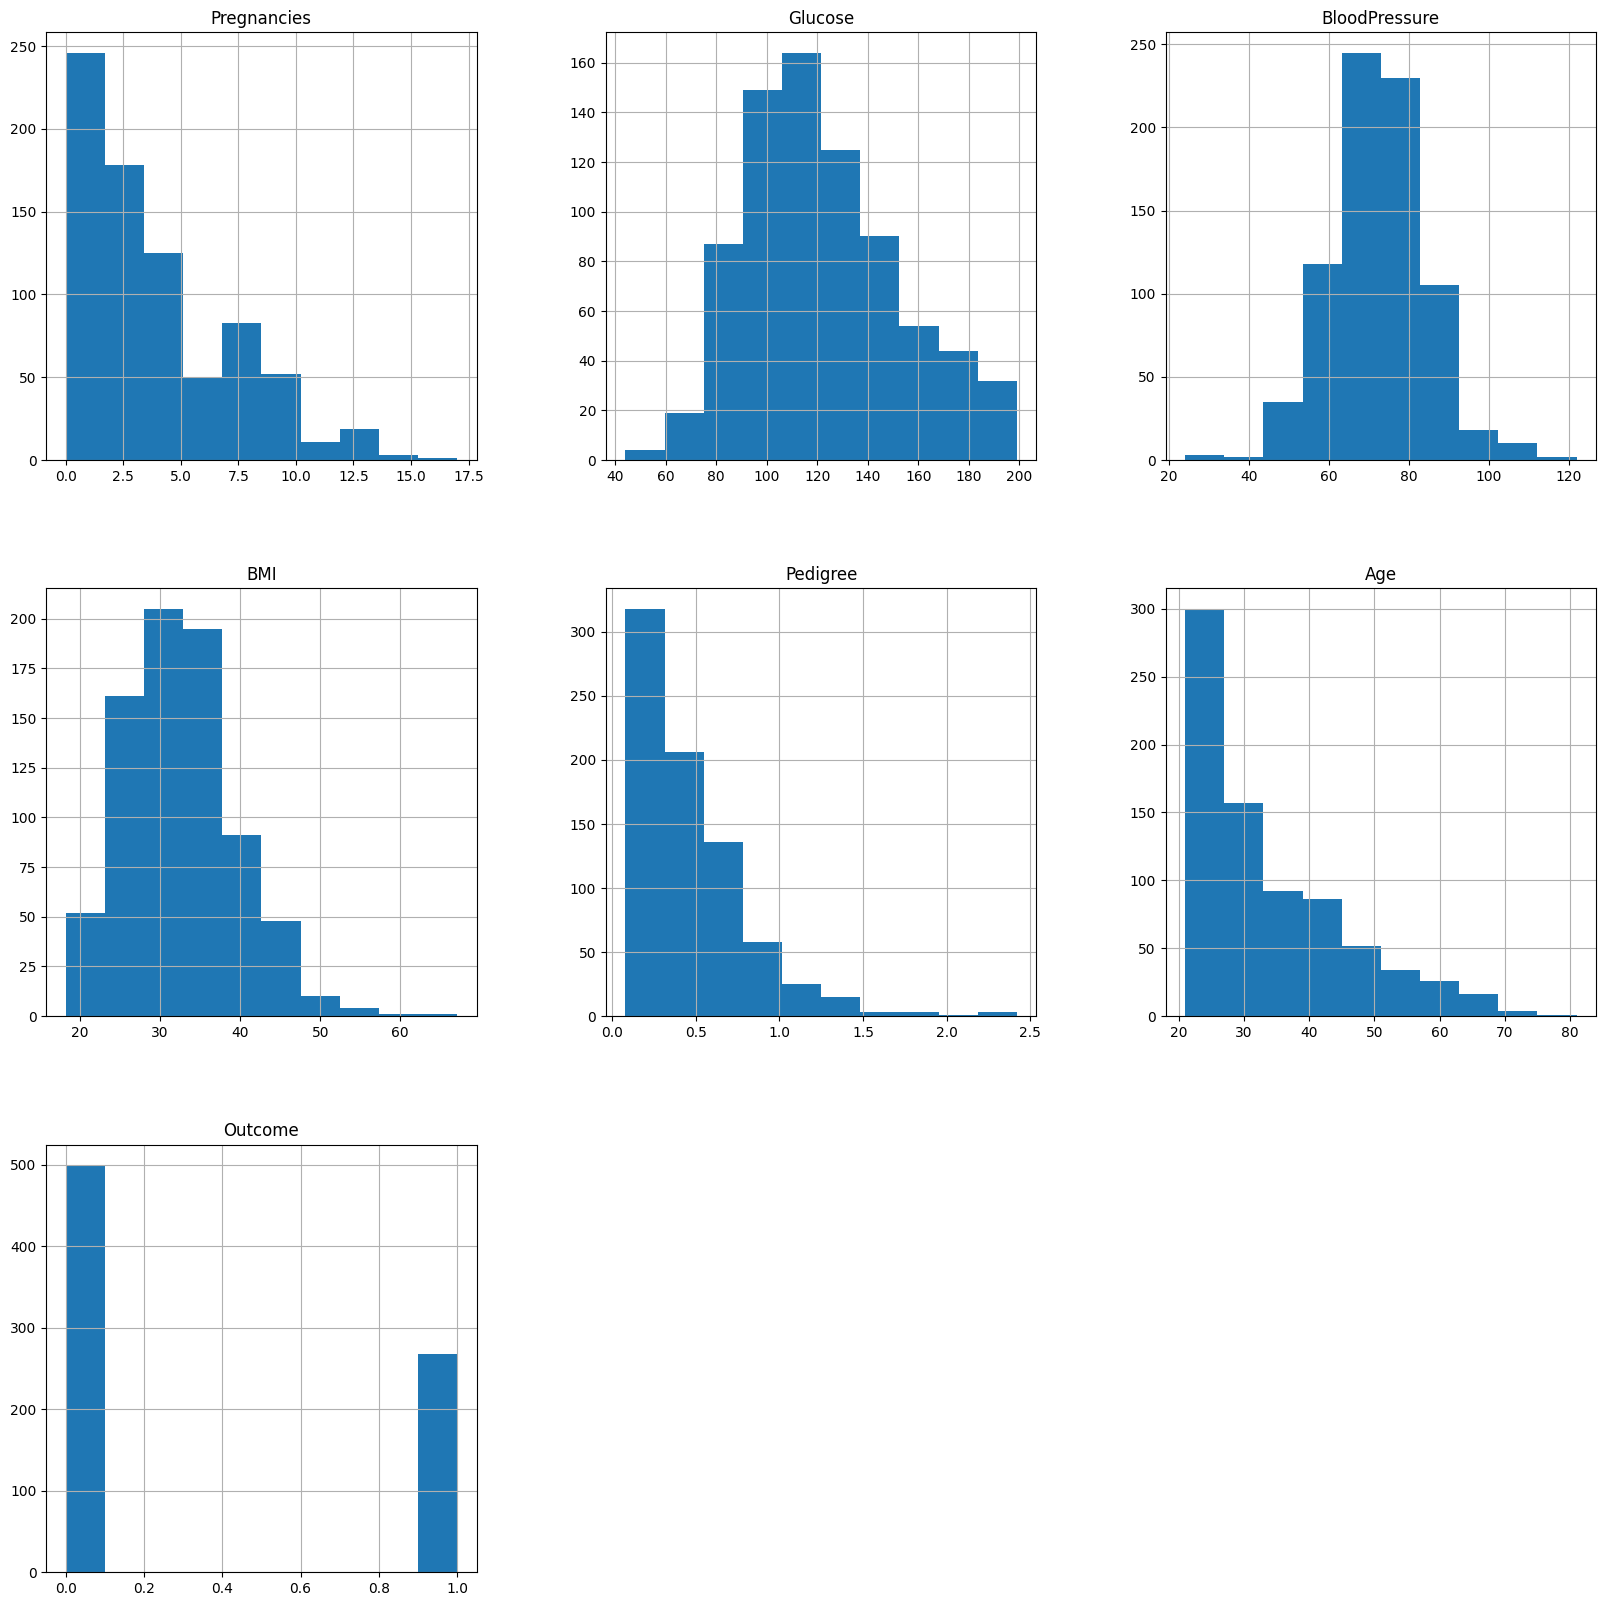

In [20]:
df.hist(figsize= (20, 20))
plt.show()

In [21]:
df.corr()

,Pregnancies,Glucose,BloodPressure,BMI,Pedigree,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.023890,-0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.286399,-0.001443,0.325135,0.174469
BMI,0.023890,0.236171,0.286399,1.000000,0.152771,0.027849,0.315577
Pedigree,-0.033523,0.138353,-0.001443,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.315577,0.173844,0.238356,1.000000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    float64
 2   BloodPressure  768 non-null    float64
 3   BMI            768 non-null    float64
 4   Pedigree       768 non-null    float64
 5   Age            768 non-null    int64  
 6   Outcome        768 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 42.1 KB


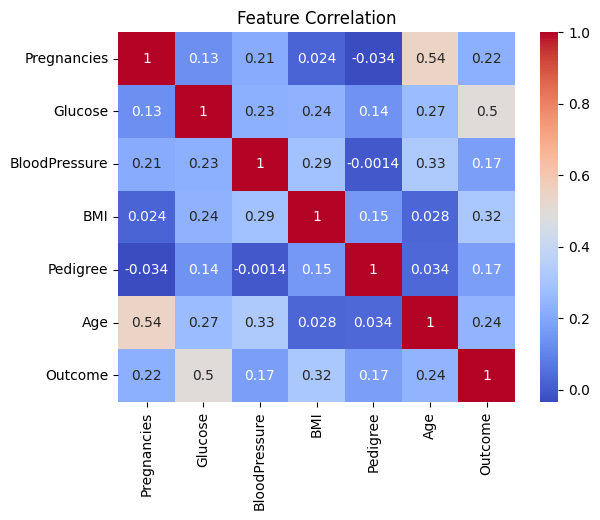

In [23]:
# Cek korelasi antar fitur
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [24]:
X = df.drop('Outcome', axis=1).values #Indepnndent
y = df['Outcome'].values #Dependent


In [25]:
def split_data_train_test(X, y, train_size=0.8, random_state=0):
  np.random.seed(random_state)
  idx = np.random.permutation(len(X))
  split = int(0.8 * len(X))

  X_train = df.drop('Outcome', axis=1).iloc[idx[:split]].values
  X_test  = df.drop('Outcome', axis=1).iloc[idx[split:]].values
  y_train = df['Outcome'].iloc[idx[:split]].values
  y_test  = df['Outcome'].iloc[idx[split:]].values

  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data_train_test(X, y)

In [26]:
def knn_predict_sensitive(X_train, y_train, X_test, k=5, min_diabetes=2):
    predictions = []
    for test_point in X_test:
        distances = []
        for i in range(len(X_train)):
            dist = np.sqrt(np.sum((test_point - X_train[i]) ** 2))
            distances.append((dist, y_train[i]))
        
        distances.sort(key=lambda x: x[0])
        k_nearest_labels = [label for _, label in distances[:k]]
        
        pred = 1 if sum(k_nearest_labels) >= min_diabetes else 0
        predictions.append(pred)
    
    return np.array(predictions)

y_pred = knn_predict_sensitive(X_train, y_train, X_test, k=5, min_diabetes=2)

In [27]:
assert len(y_test) == len(y_pred), "Error: y_test dan y_pred panjangnya beda!"

In [28]:
def classification_report(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))  # True Positive
    tn = np.sum((y_true == 0) & (y_pred == 0))  # True Negative
    fp = np.sum((y_true == 0) & (y_pred == 1))  # False Positive
    fn = np.sum((y_true == 1) & (y_pred == 0))  # False Negative
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(" Hasil Evaluasi:")
    print(f" Recall (deteksi diabetes): {recall:.2%}")
    print(f" Precision: {precision:.2%}")
    print(f" F1-Score: {f1:.2%}")
    print(f" Akurasi: {accuracy:.2%}")
    print(f" False Negative: {fn} dari {tp+fn} kasus diabetes")
    return recall, precision, f1, accuracy

recall, prec, f1, acc = classification_report(y_test, y_pred)

 Hasil Evaluasi:
 Recall (deteksi diabetes): 75.51%
 Precision: 53.62%
 F1-Score: 62.71%
 Akurasi: 71.43%
 False Negative: 12 dari 49 kasus diabetes
